# Standardization

1. Converts features with zero mean and unit variance.

2. No effect on Correlation/Covariance.

3. 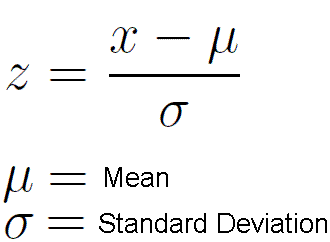

Advantages

1. Simple and efficient to use.

Disadvantages

1. Not so robust to Outliers.

2. Does not work with algos which assumes non negative values (naive Bayes Theorem)

In [133]:
import numpy as np # linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

## Impact of scaling when we have positive co-variance

C:\Users\avanindra Bose\AppData\Local\Temp\ipykernel_4680\2829098408.py:8: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  elongated_data = np.random.multivariate_normal(mean, cov, 1000)


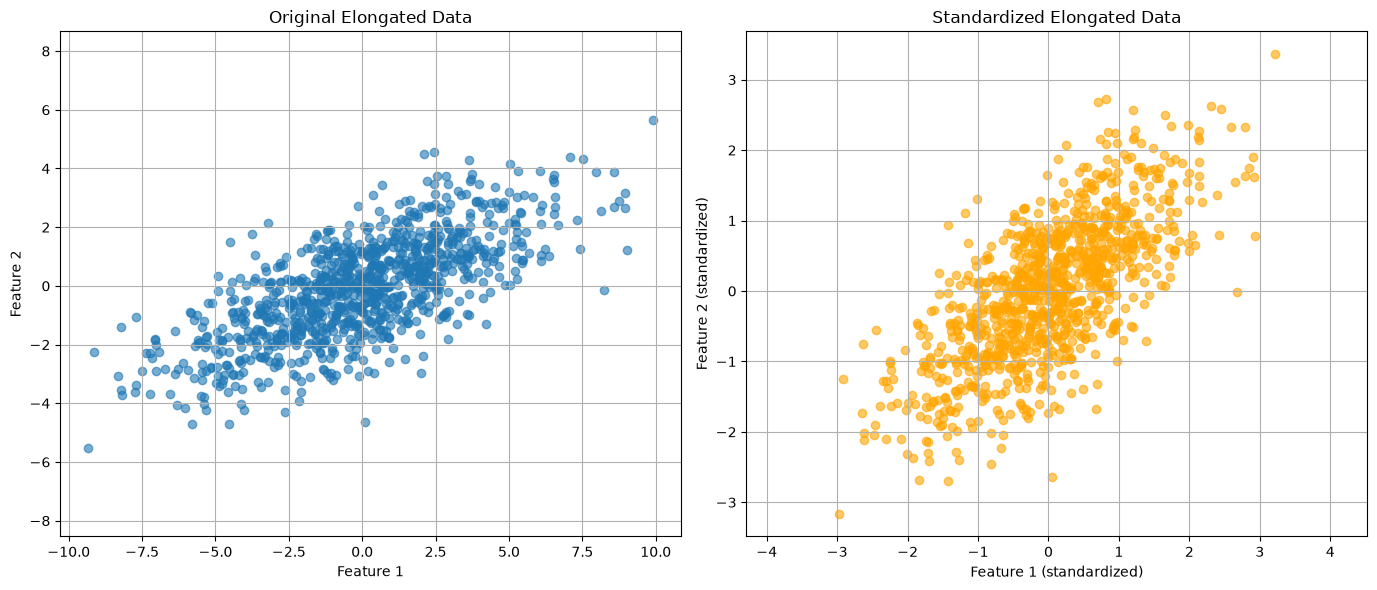

In [92]:
np.random.seed(42)

# Generate data
mean = [0, 0]
cov = [[10, 5], [5, 1]]  # Covariance matrix to create elongation

# Create an elongated ellipsoid dataset
elongated_data = np.random.multivariate_normal(mean, cov, 1000)

# Apply standardization
scaler_elongated = StandardScaler()
elongated_data_standardized = scaler_elongated.fit_transform(elongated_data)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Original Elongated Data
ax[0].scatter(elongated_data[:, 0], elongated_data[:, 1], alpha=0.6)
ax[0].set_title('Original Elongated Data')
ax[0].set_xlabel('Feature 1')
ax[0].set_ylabel('Feature 2')
ax[0].axis('equal')  # Ensuring equal axis ratios
ax[0].grid(True)

# Standardized Elongated Data
ax[1].scatter(elongated_data_standardized[:, 0], elongated_data_standardized[:, 1], alpha=0.6, color='orange')
ax[1].set_title('Standardized Elongated Data')
ax[1].set_xlabel('Feature 1 (standardized)')
ax[1].set_ylabel('Feature 2 (standardized)')
ax[1].axis('equal')  # Ensuring equal axis ratios
ax[1].grid(True)

plt.tight_layout()
plt.show()

## Impact of scaling when we have Zero co-variance

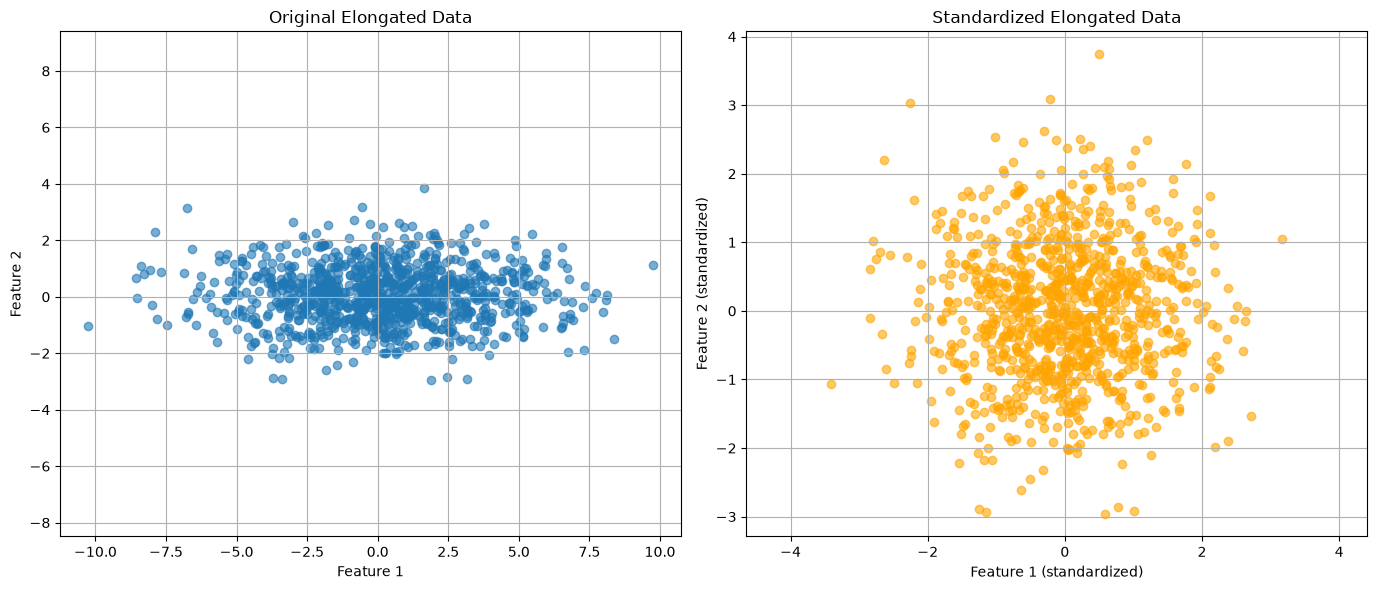

In [93]:
# Generating elongated ellipsoid data
np.random.seed(42)

# Generate data
mean = [0, 0]
cov = [[10, 0], [0, 1]]  # Covariance matrix to create elongation

# Create an elongated ellipsoid dataset
elongated_data = np.random.multivariate_normal(mean, cov, 1000)

# Apply standardization
scaler_elongated = StandardScaler()
elongated_data_standardized = scaler_elongated.fit_transform(elongated_data)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Original Elongated Data
ax[0].scatter(elongated_data[:, 0], elongated_data[:, 1], alpha=0.6)
ax[0].set_title('Original Elongated Data')
ax[0].set_xlabel('Feature 1')
ax[0].set_ylabel('Feature 2')
ax[0].axis('equal')  # Ensuring equal axis ratios
ax[0].grid(True)

# Standardized Elongated Data
ax[1].scatter(elongated_data_standardized[:, 0], elongated_data_standardized[:, 1], alpha=0.6, color='orange')
ax[1].set_title('Standardized Elongated Data')
ax[1].set_xlabel('Feature 1 (standardized)')
ax[1].set_ylabel('Feature 2 (standardized)')
ax[1].axis('equal')  # Ensuring equal axis ratios
ax[1].grid(True)

plt.tight_layout()
plt.show()

## Impact of scaling when we have Negative co-variance

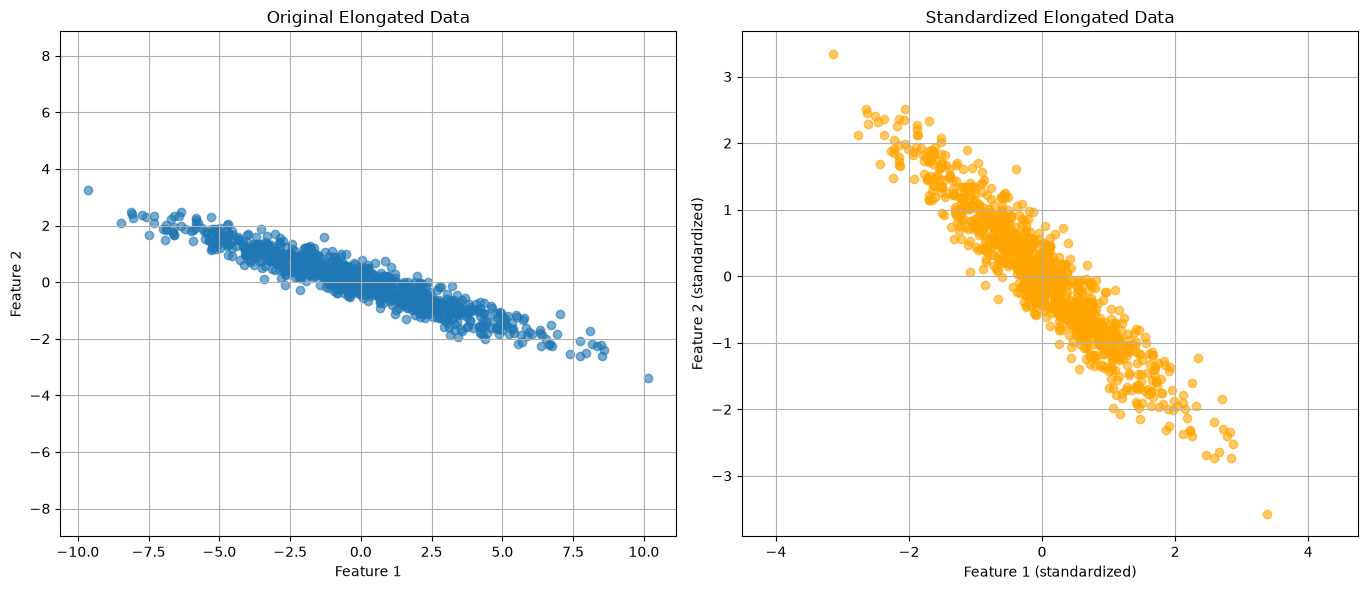

In [94]:
# Generating elongated ellipsoid data
np.random.seed(42)

# Generate data
mean = [0, 0]
cov = [[10, -3], [-3, 1]]  # Covariance matrix to create elongation

# Create an elongated ellipsoid dataset
elongated_data = np.random.multivariate_normal(mean, cov, 1000)

# Apply standardization
scaler_elongated = StandardScaler()
elongated_data_standardized = scaler_elongated.fit_transform(elongated_data)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Original Elongated Data
ax[0].scatter(elongated_data[:, 0], elongated_data[:, 1], alpha=0.6)
ax[0].set_title('Original Elongated Data')
ax[0].set_xlabel('Feature 1')
ax[0].set_ylabel('Feature 2')
ax[0].axis('equal')  # Ensuring equal axis ratios
ax[0].grid(True)

# Standardized Elongated Data
ax[1].scatter(elongated_data_standardized[:, 0], elongated_data_standardized[:, 1], alpha=0.6, color='orange')
ax[1].set_title('Standardized Elongated Data')
ax[1].set_xlabel('Feature 1 (standardized)')
ax[1].set_ylabel('Feature 2 (standardized)')
ax[1].axis('equal')  # Ensuring equal axis ratios
ax[1].grid(True)

plt.tight_layout()
plt.show()

## Summary :

1. In Nutshell standard scaler after transformation do not make the distribution of the data spherical.

2. StandardScaler makes each feature have mean 0 and variance 1, while preserving the correlation structure between features.

3. It changes the location and scale of each column but does not fundamentally change the shape of its distribution.

In [95]:
df = pd.read_csv('https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/main/day24-standardization/Social_Network_Ads.csv')

In [96]:
df=df.iloc[:,2:]

In [97]:
df.sample(5)

,Age,EstimatedSalary,Purchased
355,60,34000,1
72,20,23000,0
34,27,90000,0
370,60,46000,1
90,22,81000,0


In [98]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((280, 2), (120, 2))

In [99]:
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)
# mean, std

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [101]:
X_train

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [102]:
X_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [103]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [104]:
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [105]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


## Effect of Scaling

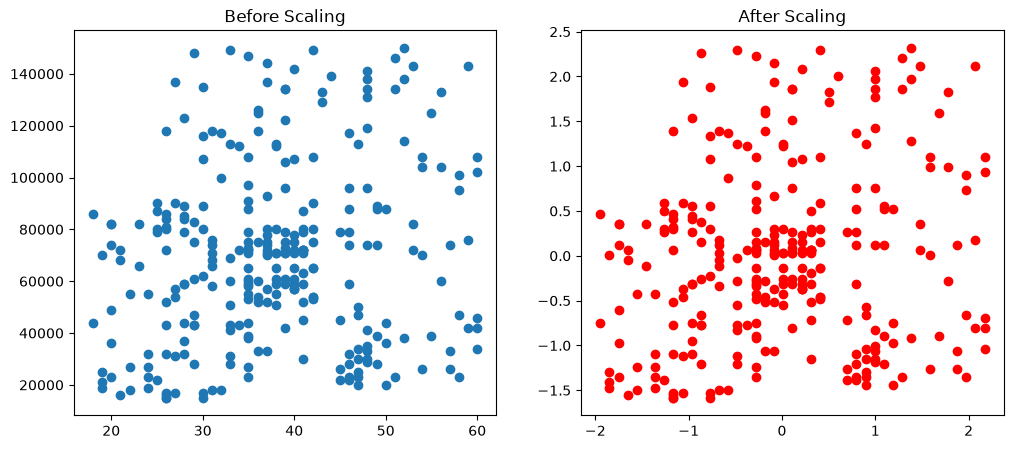

In [106]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()

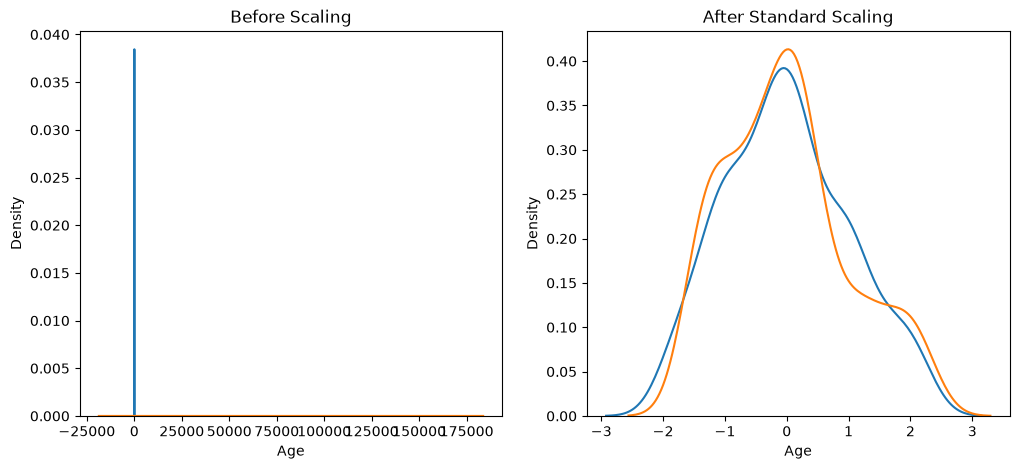

In [107]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

## Comparison of Individual Distributions

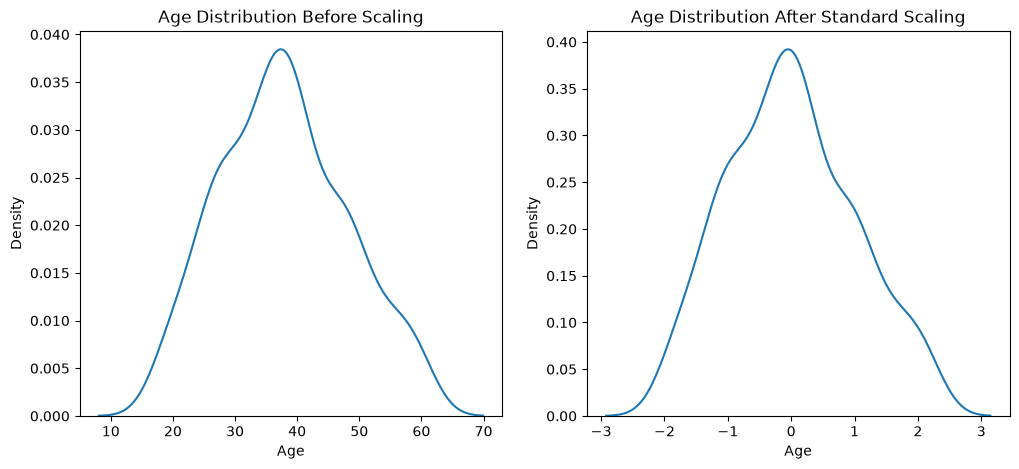

In [108]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Age Distribution Before Scaling')
sns.kdeplot(X_train['Age'], ax=ax1)

# after scaling
ax2.set_title('Age Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['Age'], ax=ax2)
plt.show()

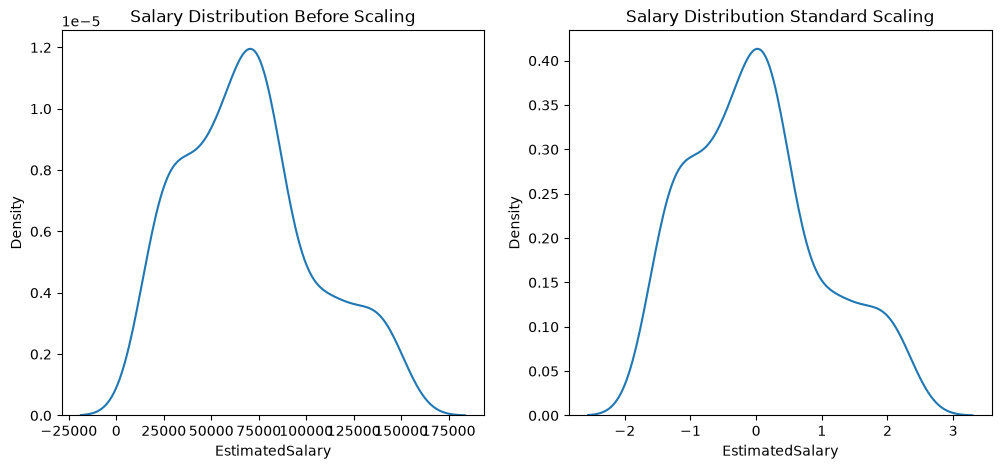

In [109]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

## Impact of Outliers

In [126]:
df = pd.concat([df, pd.DataFrame({'Age':[5,90,95],'EstimatedSalary':[1000,250000,350000],'Purchased':[0,1,1]})], ignore_index=True)

In [127]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
401,90,250000,1
402,95,350000,1
403,5,1000,0
404,90,250000,1


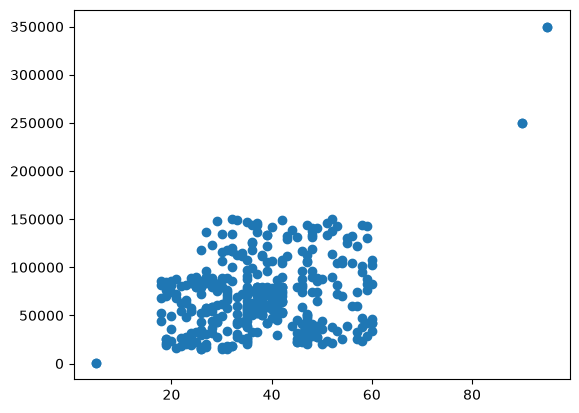

In [128]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [129]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((284, 2), (122, 2))

In [130]:
scaler = StandardScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [131]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

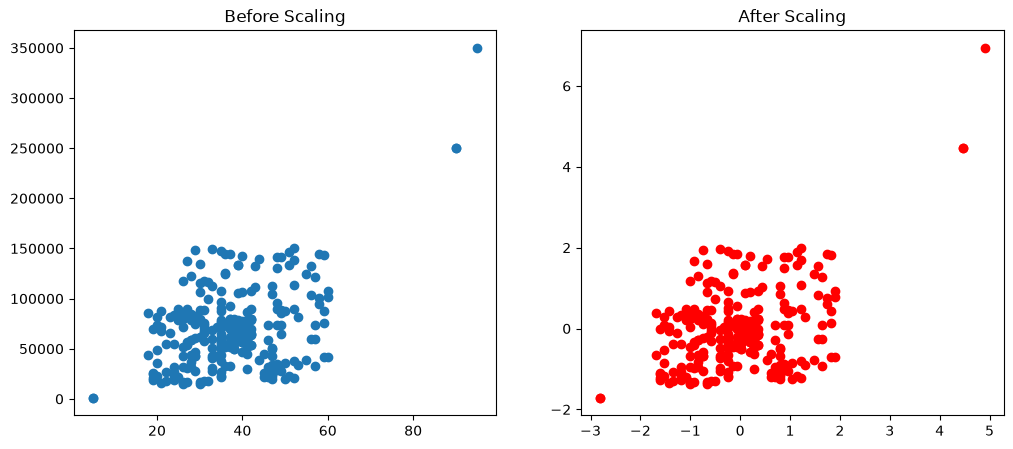

In [132]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'],color='red')
ax2.set_title("After Scaling")
plt.show()